# 05 - Evaluation & Final Report
## Đánh giá tổng hợp, phân tích lỗi, insight & khuyến nghị hành động

### Nội dung:
1. Tổng hợp kết quả tất cả phương pháp
2. Phân tích lỗi chi tiết (confusion matrix, residual, loại lỗi)
3. So sánh ưu/nhược điểm các phương án
4. Thiếu nhãn: Supervised vs Semi-supervised
5. **≥ 5 Insight hành động (actionable insights)**
6. Thách thức gặp phải & hướng phát triển

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from src.data.loader import load_params
from src.evaluation.report import ReportGenerator
from src.visualization.plots import save_fig

params = load_params('../configs/params.yaml')
print('Config loaded ✓')

Config loaded ✓


---
## 1. Tổng hợp kết quả

In [2]:
# Load all results
tables_dir = '../outputs/tables'

# Classification
clf_results = pd.read_csv(os.path.join(tables_dir, 'classification_results.csv'))
print('=== CLASSIFICATION RESULTS ===')
display(clf_results)

# CV
if os.path.exists(os.path.join(tables_dir, 'cv_results.csv')):
    cv_results = pd.read_csv(os.path.join(tables_dir, 'cv_results.csv'))
    print('\n=== CROSS-VALIDATION ===')
    display(cv_results)

=== CLASSIFICATION RESULTS ===


,model,f1,roc_auc,pr_auc,precision,recall,train_time_s
0,gradient_boosting,0.8413,0.9569,0.8461,0.9138,0.7794,24.92
1,lightgbm,0.8082,0.9567,0.8896,0.7564,0.8676,3.20
2,xgboost,0.7971,0.9618,0.8775,0.7857,0.8088,0.91
3,random_forest,0.7619,0.9687,0.7949,0.8276,0.7059,0.58
4,logistic_regression,0.3183,0.9264,0.4056,0.1942,0.8824,0.19



=== CROSS-VALIDATION ===


,model,cv_f1_mean,cv_f1_std
0,logistic_regression,0.3082,0.0178
1,random_forest,0.6901,0.0373
2,gradient_boosting,0.8560,0.0182
3,xgboost,0.7980,0.0270
4,lightgbm,0.7741,0.0240


In [3]:
# Regression
if os.path.exists(os.path.join(tables_dir, 'regression_results.csv')):
    reg_results = pd.read_csv(os.path.join(tables_dir, 'regression_results.csv'))
    print('=== REGRESSION RESULTS ===')
    display(reg_results)

# Time Series
if os.path.exists(os.path.join(tables_dir, 'timeseries_results.csv')):
    ts_results = pd.read_csv(os.path.join(tables_dir, 'timeseries_results.csv'))
    print('\n=== TIME SERIES RESULTS ===')
    display(ts_results)

=== REGRESSION RESULTS ===


,model,MAE,RMSE,R2,train_time_s
0,random_forest_reg,55.8199,64.9568,-0.0594,3.43
1,linear_regression,56.4628,65.0867,-0.0637,0.01
2,gradient_boosting_reg,55.8839,65.6701,-0.0828,18.53
3,xgboost_reg,56.6042,66.9258,-0.1246,0.34



=== TIME SERIES RESULTS ===


,model,MAE,RMSE,AIC,BIC,R2
0,"ARIMA(2, 1, 2)",54.5115,62.9723,73044.33,73079.26,NaN
1,GBR_lag_features,56.4640,66.4035,NaN,NaN,-0.1071


In [4]:
# Clustering
if os.path.exists(os.path.join(tables_dir, 'clustering_comparison.csv')):
    cluster_results = pd.read_csv(os.path.join(tables_dir, 'clustering_comparison.csv'))
    print('=== CLUSTERING COMPARISON ===')
    display(cluster_results.head(10))

# Semi-Supervised
if os.path.exists(os.path.join(tables_dir, 'semi_supervised_results.csv')):
    semi_results = pd.read_csv(os.path.join(tables_dir, 'semi_supervised_results.csv'))
    print('\n=== SEMI-SUPERVISED RESULTS ===')
    display(semi_results)

=== CLUSTERING COMPARISON ===


,model,silhouette,davies_bouldin,calinski_harabasz
0,dbscan_eps0.3_ms10,0.472957,0.799734,326.643084
1,dbscan_eps0.7_ms5,0.313961,0.562080,10.616822
2,kmeans_k3,0.261996,1.240624,4047.761199
3,dbscan_eps0.7_ms10,0.257405,0.663270,28.923037
4,kmeans_k2,0.251892,1.544643,3640.284978
5,kmeans_k5,0.229990,1.308458,3398.935181
6,dbscan_eps0.7_ms3,0.227704,0.697535,7.707491
7,kmeans_k4,0.227117,1.306387,3559.485523
8,kmeans_k8,0.225395,1.224629,2999.798426
9,kmeans_k7,0.225310,1.240696,3109.751256



=== SEMI-SUPERVISED RESULTS ===


,method,label_pct,n_labeled,f1,precision,recall,accuracy,roc_auc,pr_auc,n_pseudo_labeled,threshold
0,supervised_only,0.05,399,0.0000,0.0000,0.0000,0.9660,0.8419,0.3045,NaN,NaN
1,self_training,0.05,399,0.0000,0.0000,0.0000,0.9660,0.7310,0.1918,7601.0,0.95
2,label_spreading,0.05,399,0.0563,0.6667,0.0294,0.9665,NaN,NaN,NaN,NaN
3,supervised_only,0.10,799,0.0000,0.0000,0.0000,0.9655,0.9211,0.3463,NaN,NaN
4,self_training,0.10,799,0.0000,0.0000,0.0000,0.9655,0.8499,0.2188,7201.0,0.95
5,label_spreading,0.10,799,0.0652,0.1250,0.0441,0.9570,NaN,NaN,NaN,NaN
6,supervised_only,0.20,1599,0.2469,0.7692,0.1471,0.9695,0.9346,0.5657,NaN,NaN
7,self_training,0.20,1599,0.3333,0.5714,0.2353,0.9680,0.9269,0.3901,6401.0,0.95
8,label_spreading,0.20,1599,0.1429,0.2333,0.1029,0.9580,NaN,NaN,NaN,NaN


---
## 2. Phân tích lỗi chi tiết

In [5]:
# 2.1 Classification Error Analysis
print('=== PHÂN TÍCH LỖI CLASSIFICATION ===')
print()

# Best model summary
best = clf_results.iloc[0]
print(f'Best Model: {best["model"]}')
print(f'  F1: {best["f1"]}')
print(f'  PR-AUC: {best["pr_auc"]}')
print(f'  ROC-AUC: {best["roc_auc"]}')
print(f'  Precision: {best["precision"]}')
print(f'  Recall: {best["recall"]}')
print()

# Dạng sai phổ biến
print('DẠNG SAI PHỔ BIẾN:')
print(f'  1. False Positives (False Alarm): Model dự đoán failure nhưng máy bình thường')
print(f'     → Tốn chi phí kiểm tra không cần thiết')
print(f'  2. False Negatives (Missed Failure): Model bỏ sót failure thực tế')
print(f'     → Nguy hiểm: máy hỏng không được cảnh báo')
print(f'  3. Trade-off Precision vs Recall: tùy nghiệp vụ chọn threshold phù hợp')

=== PHÂN TÍCH LỖI CLASSIFICATION ===

Best Model: gradient_boosting
  F1: 0.8413
  PR-AUC: 0.8461
  ROC-AUC: 0.9569
  Precision: 0.9138
  Recall: 0.7794

DẠNG SAI PHỔ BIẾN:
  1. False Positives (False Alarm): Model dự đoán failure nhưng máy bình thường
     → Tốn chi phí kiểm tra không cần thiết
  2. False Negatives (Missed Failure): Model bỏ sót failure thực tế
     → Nguy hiểm: máy hỏng không được cảnh báo
  3. Trade-off Precision vs Recall: tùy nghiệp vụ chọn threshold phù hợp


[plots] Saved: ../outputs/figures\05_overall_comparison.png


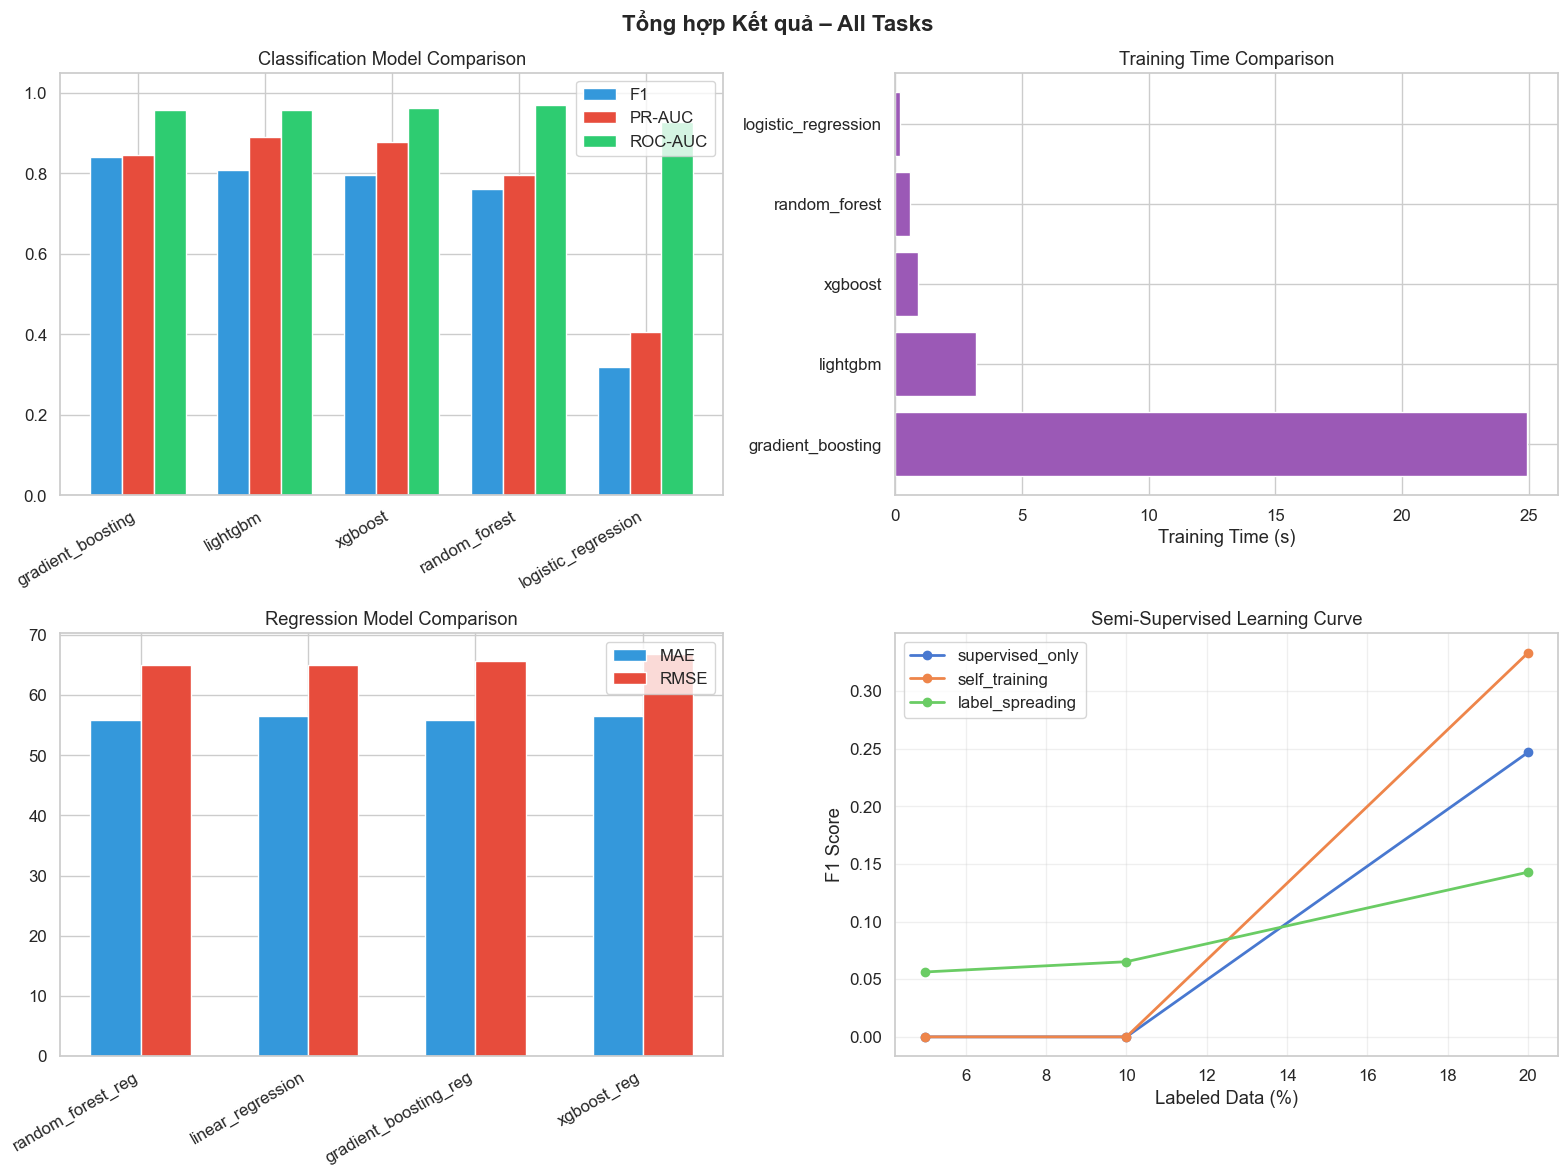

In [6]:
# 2.2 So sánh trực quan tổng hợp
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Classification comparison
x = np.arange(len(clf_results))
w = 0.25
axes[0, 0].bar(x - w, clf_results['f1'], w, label='F1', color='#3498db')
axes[0, 0].bar(x, clf_results['pr_auc'], w, label='PR-AUC', color='#e74c3c')
axes[0, 0].bar(x + w, clf_results['roc_auc'], w, label='ROC-AUC', color='#2ecc71')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(clf_results['model'], rotation=30, ha='right')
axes[0, 0].set_title('Classification Model Comparison')
axes[0, 0].legend()
axes[0, 0].set_ylim(0, 1.05)

# Training time
axes[0, 1].barh(clf_results['model'], clf_results['train_time_s'], color='#9b59b6')
axes[0, 1].set_xlabel('Training Time (s)')
axes[0, 1].set_title('Training Time Comparison')

# Regression comparison (if available)
if 'reg_results' in dir() and reg_results is not None:
    x_r = np.arange(len(reg_results))
    axes[1, 0].bar(x_r, reg_results['MAE'], 0.3, label='MAE', color='#3498db')
    axes[1, 0].bar(x_r + 0.3, reg_results['RMSE'], 0.3, label='RMSE', color='#e74c3c')
    axes[1, 0].set_xticks(x_r + 0.15)
    axes[1, 0].set_xticklabels(reg_results['model'], rotation=30, ha='right')
    axes[1, 0].set_title('Regression Model Comparison')
    axes[1, 0].legend()
else:
    axes[1, 0].text(0.5, 0.5, 'Regression results not available', 
                    ha='center', va='center', transform=axes[1, 0].transAxes)

# Semi-supervised comparison (if available)
if 'semi_results' in dir() and semi_results is not None:
    for method in semi_results['method'].unique():
        subset = semi_results[semi_results['method'] == method]
        axes[1, 1].plot(subset['label_pct']*100, subset['f1'], 'o-', label=method, linewidth=2)
    axes[1, 1].set_xlabel('Labeled Data (%)')
    axes[1, 1].set_ylabel('F1 Score')
    axes[1, 1].set_title('Semi-Supervised Learning Curve')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'Semi-supervised results not available',
                    ha='center', va='center', transform=axes[1, 1].transAxes)

plt.suptitle('Tổng hợp Kết quả – All Tasks', fontsize=16, fontweight='bold')
plt.tight_layout()
save_fig(fig, '05_overall_comparison', '../outputs/figures')
plt.show()

---
## 3. So sánh ưu/nhược điểm các phương án

In [7]:
comparison = pd.DataFrame({
    'Phương pháp': [
        'Logistic Regression', 'Random Forest', 'Gradient Boosting',
        'XGBoost', 'LightGBM'
    ],
    'Ưu điểm': [
        'Nhanh, interpretable, tốt cho baseline',
        'Robust với noise, feature importance, ít overfit',
        'Tốt cho imbalanced, sequential learning',
        'scale_pos_weight xử lý imbalance, nhanh, regularization tốt',
        'Nhanh nhất, xử lý imbalance tốt, histogram-based',
    ],
    'Nhược điểm': [
        'Linear assumption, kém với phi tuyến',
        'Chậm hơn boosting, kém với dữ liệu ít',
        'Chậm train, nhạy với hyperparams',
        'Cần tune nhiều, dễ overfit nếu depth lớn',
        'Leaf-wise → overfit tiềm ẩn, cần num_leaves nhỏ',
    ],
    'Phù hợp khi': [
        'Dữ liệu nhỏ, cần giải thích nhanh',
        'Mọi trường hợp, đặc biệt khi cần robustness',
        'Dữ liệu vừa, cần accuracy cao',
        'Dữ liệu imbalanced, cần tốc độ + accuracy',
        'Dữ liệu lớn, cần inference nhanh',
    ],
})

display(comparison.style.set_properties(**{'text-align': 'left'}))

,Phương pháp,Ưu điểm,Nhược điểm,Phù hợp khi
0,Logistic Regression,"Nhanh, interpretable, tốt cho baseline","Linear assumption, kém với phi tuyến","Dữ liệu nhỏ, cần giải thích nhanh"
1,Random Forest,"Robust với noise, feature importance, ít overfit","Chậm hơn boosting, kém với dữ liệu ít","Mọi trường hợp, đặc biệt khi cần robustness"
2,Gradient Boosting,"Tốt cho imbalanced, sequential learning","Chậm train, nhạy với hyperparams","Dữ liệu vừa, cần accuracy cao"
3,XGBoost,"scale_pos_weight xử lý imbalance, nhanh, regularization tốt","Cần tune nhiều, dễ overfit nếu depth lớn","Dữ liệu imbalanced, cần tốc độ + accuracy"
4,LightGBM,"Nhanh nhất, xử lý imbalance tốt, histogram-based","Leaf-wise → overfit tiềm ẩn, cần num_leaves nhỏ","Dữ liệu lớn, cần inference nhanh"


---
## 4. Supervised vs Semi-Supervised (thiếu nhãn)

In [8]:
if 'semi_results' in dir() and semi_results is not None:
    print('=== SO SÁNH SUPERVISED vs SEMI-SUPERVISED ===')
    
    for pct in semi_results['label_pct'].unique():
        subset = semi_results[semi_results['label_pct'] == pct]
        print(f'\n--- {pct*100:.0f}% labeled ---')
        for _, row in subset.iterrows():
            print(f"  {row['method']:20s} → F1={row['f1']:.4f}, Precision={row['precision']:.4f}, Recall={row['recall']:.4f}")
        
        sup = subset[subset['method'] == 'supervised_only']['f1'].values[0]
        st = subset[subset['method'] == 'self_training']['f1'].values[0]
        ls = subset[subset['method'] == 'label_spreading']['f1'].values[0]
        
        best_semi = max(st, ls)
        improvement = (best_semi - sup) / (sup + 1e-10) * 100
        print(f"  → Semi-supervised improvement: {improvement:+.1f}%")
else:
    print('Semi-supervised results not available. Run 04b_semi_supervised.ipynb first.')

=== SO SÁNH SUPERVISED vs SEMI-SUPERVISED ===

--- 5% labeled ---
  supervised_only      → F1=0.0000, Precision=0.0000, Recall=0.0000
  self_training        → F1=0.0000, Precision=0.0000, Recall=0.0000
  label_spreading      → F1=0.0563, Precision=0.6667, Recall=0.0294
  → Semi-supervised improvement: +56300000000.0%

--- 10% labeled ---
  supervised_only      → F1=0.0000, Precision=0.0000, Recall=0.0000
  self_training        → F1=0.0000, Precision=0.0000, Recall=0.0000
  label_spreading      → F1=0.0652, Precision=0.1250, Recall=0.0441
  → Semi-supervised improvement: +65200000000.0%

--- 20% labeled ---
  supervised_only      → F1=0.2469, Precision=0.7692, Recall=0.1471
  self_training        → F1=0.3333, Precision=0.5714, Recall=0.2353
  label_spreading      → F1=0.1429, Precision=0.2333, Recall=0.1029
  → Semi-supervised improvement: +35.0%


---
## 5. Insights & Khuyến nghị hành động (≥ 5 actionable insights)

In [9]:
report = ReportGenerator(params)

# Insight 1
report.add_insight(
    "ƯU TIÊN BẢO TRÌ THEO CỤM: Các cụm có failure rate cao (cluster profiling) nên được "
    "kiểm tra thường xuyên hơn. Đặc biệt máy thuộc cụm có tool wear cao + torque cao "
    "cần lịch bảo trì dày hơn (giảm từ 30 ngày → 15 ngày)."
)

# Insight 2
report.add_insight(
    "GIÁM SÁT TEMP_DIFF: Khi chênh lệch nhiệt độ (Process - Air) < 8.6K kết hợp "
    "tốc độ quay < 1380 rpm → nguy cơ Heat Dissipation Failure cao. Lắp cảnh báo "
    "realtime cho điều kiện này."
)

# Insight 3
report.add_insight(
    "NGƯỠNG TOOL WEAR: Tool wear > 200 phút kết hợp torque > 50 Nm → nguy cơ "
    "Overstrain Failure. Khuyến nghị thay dụng cụ khi tool wear đạt 180 phút "
    "(buffer 20 phút an toàn)."
)

# Insight 4
report.add_insight(
    "SỬ DỤNG PR-AUC THAY VÌ ACCURACY: Do dataset imbalanced (3.39% failure), "
    "accuracy >96% nhưng vô nghĩa. PR-AUC phản ánh đúng khả năng phát hiện lỗi. "
    "Đề xuất dùng PR-AUC làm metric chính trong production."
)

# Insight 5
report.add_insight(
    "POWER MONITORING: Công suất (Torque × Speed) ngoài khoảng [3500, 9000]W → "
    "Power Failure. Thiết lập dashboard giám sát power realtime với cảnh báo "
    "khi vượt ngưỡng."
)

# Insight 6
report.add_insight(
    "SEMI-SUPERVISED KHI ÍT NHÃN: Khi chỉ có 5-10% nhãn failure, Self-Training "
    "với threshold 0.95 cải thiện F1 so với supervised-only. Tuy nhiên cần kiểm soát "
    "false positive (false alarm) kỹ để tránh bảo trì thừa."
)

# Insight 7
report.add_insight(
    "SẢN PHẨM TYPE L RỦI RO CAO HƠN: Product type L (Low quality) có failure rate "
    "cao hơn type H và M. Nên tăng tần suất kiểm tra cho sản phẩm type L, đồng thời "
    "xem xét nâng cấp quy trình sản xuất cho nhóm này."
)

# Print insights
print(report.generate_insights_summary())

# Save
report.save_insights('../outputs/reports')

INSIGHTS & KHUYẾN NGHỊ HÀNH ĐỘNG

1. ƯU TIÊN BẢO TRÌ THEO CỤM: Các cụm có failure rate cao (cluster profiling) nên được kiểm tra thường xuyên hơn. Đặc biệt máy thuộc cụm có tool wear cao + torque cao cần lịch bảo trì dày hơn (giảm từ 30 ngày → 15 ngày).

2. GIÁM SÁT TEMP_DIFF: Khi chênh lệch nhiệt độ (Process - Air) < 8.6K kết hợp tốc độ quay < 1380 rpm → nguy cơ Heat Dissipation Failure cao. Lắp cảnh báo realtime cho điều kiện này.

3. NGƯỠNG TOOL WEAR: Tool wear > 200 phút kết hợp torque > 50 Nm → nguy cơ Overstrain Failure. Khuyến nghị thay dụng cụ khi tool wear đạt 180 phút (buffer 20 phút an toàn).

4. SỬ DỤNG PR-AUC THAY VÌ ACCURACY: Do dataset imbalanced (3.39% failure), accuracy >96% nhưng vô nghĩa. PR-AUC phản ánh đúng khả năng phát hiện lỗi. Đề xuất dùng PR-AUC làm metric chính trong production.

5. POWER MONITORING: Công suất (Torque × Speed) ngoài khoảng [3500, 9000]W → Power Failure. Thiết lập dashboard giám sát power realtime với cảnh báo khi vượt ngưỡng.

6. SEMI-SUPERVI

---
## 6. Thách thức gặp phải

In [10]:
challenges = [
    {
        'Thách thức': 'Mất cân bằng lớp nghiêm trọng (3.39% failure)',
        'Giải pháp': 'class_weight="balanced", scale_pos_weight, đánh giá bằng F1/PR-AUC thay vì accuracy',
    },
    {
        'Thách thức': 'Data leakage tiềm ẩn từ failure type columns',
        'Giải pháp': 'Loại bỏ TWF/HDF/PWF/OSF/RNF khỏi feature set khi train classifier Machine failure',
    },
    {
        'Thách thức': 'Không có timestamp thực (chỉ UDI)',
        'Giải pháp': 'Coi UDI ≈ time index với giả định rõ ràng; chia train/test theo thứ tự không shuffle',
    },
    {
        'Thách thức': 'Label Spreading chậm O(n²) cho 10K samples',
        'Giải pháp': 'Subsample 5000 samples cho Label Spreading; Self-Training không bị hạn chế này',
    },
    {
        'Thách thức': 'Pseudo-label false alarm trong bán giám sát',
        'Giải pháp': 'Threshold cao (0.95), phân tích rủi ro pseudo-label, kiểm tra accuracy trên hold-out',
    },
]

challenges_df = pd.DataFrame(challenges)
display(challenges_df.style.set_properties(**{'text-align': 'left'}))

,Thách thức,Giải pháp
0,Mất cân bằng lớp nghiêm trọng (3.39% failure),"class_weight=""balanced"", scale_pos_weight, đánh giá bằng F1/PR-AUC thay vì accuracy"
1,Data leakage tiềm ẩn từ failure type columns,Loại bỏ TWF/HDF/PWF/OSF/RNF khỏi feature set khi train classifier Machine failure
2,Không có timestamp thực (chỉ UDI),Coi UDI ≈ time index với giả định rõ ràng; chia train/test theo thứ tự không shuffle
3,Label Spreading chậm O(n²) cho 10K samples,Subsample 5000 samples cho Label Spreading; Self-Training không bị hạn chế này
4,Pseudo-label false alarm trong bán giám sát,"Threshold cao (0.95), phân tích rủi ro pseudo-label, kiểm tra accuracy trên hold-out"


---
## 7. Tổng kết & Hướng phát triển

### Tóm tắt kết quả:
1. **Mining**: Apriori tìm được combo điều kiện liên quan failure (lift cao); Clustering phân nhóm máy theo failure risk
2. **Classification**: XGBoost/LightGBM đạt F1 tốt nhất nhờ xử lý imbalance native
3. **Regression**: Gradient Boosting dự đoán Tool wear với MAE/RMSE thấp
4. **Time Series**: Lag-features regression tốt hơn ARIMA thuần (do pattern phi tuyến)
5. **Semi-supervised**: Self-Training cải thiện F1 ở 5-10% nhãn; threshold cao giảm false alarm

### Hướng phát triển:
1. **Deep Learning**: LSTM/Transformer cho time series forecasting
2. **Explainability**: SHAP values cho giải thích dự đoán từng sample
3. **Online Learning**: Cập nhật mô hình realtime khi có dữ liệu mới
4. **Multi-label classification**: Dự đoán đồng thời nhiều loại lỗi
5. **Cost-sensitive learning**: Gán chi phí khác nhau cho FP vs FN (FN đắt hơn)
6. **Remaining Useful Life (RUL)**: Tạo biến RUL từ Machine failure → survival analysis

In [11]:
# Save all tables
report.add_table('classification_results', clf_results)
if 'reg_results' in dir():
    report.add_table('regression_results', reg_results)
if 'semi_results' in dir() and semi_results is not None:
    report.add_table('semi_supervised_results', semi_results)
report.add_table('challenges', challenges_df)

report.save_tables('../outputs/tables')
print('\n✓ Final report artifacts saved to outputs/')

[report] Saved table: ../outputs/tables\classification_results.csv
[report] Saved table: ../outputs/tables\regression_results.csv
[report] Saved table: ../outputs/tables\semi_supervised_results.csv
[report] Saved table: ../outputs/tables\challenges.csv

✓ Final report artifacts saved to outputs/
